In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

In [46]:
from mapa_ciencia_unc import data_handlers

## Read enrollments

In [89]:
MERGED_DATA_DIRPATH = Path('../../../toshare/pri/2_merged_sampled_data/')
PUBLIC_COLS_ENROLLMENT = ['name', 'gender', 'academic_unit', 'last_project_title']

In [96]:
df_enrollment = pd.read_json(MERGED_DATA_DIRPATH / 'enrollment.json', lines=True)
df_enrollment.shape

(739, 15)

In [91]:
df_enrollment[PUBLIC_COLS_ENROLLMENT].sample(10)

,name,gender,academic_unit,last_project_title
211,Marco Antonio,Hombre,FCM,Gestión de la movilidad académica de docentes ...
694,Sofia,Mujer,FCE,Transición hacia la economía circular y la bio...
401,Silvina,Mujer,FCM,Efectos de la exposición al ftalato DEHP sobre...
616,eugenia,Mujer,"FCE, FFyH",Investigación histórico-crítica de teorías y a...
556,Luciana Estefanía,Mujer,FCM,El masaje infantil como estrategia para la pre...
25,Félix Marcelo,Hombre,"FCC, FCS",None
299,María Cecilia,Mujer,"FFyH, FL",Antropologías del gestionar: exploraciones sob...
250,Hebe,Mujer,FCEFyN,ANÁLISIS DE FUENTES DE EMISIÓN DE PARTÍCULAS A...
314,Maximiliano José,Hombre,FFyH,Arendt en las disputas del presente político a...
174,Amadeo,Hombre,FFyH,None


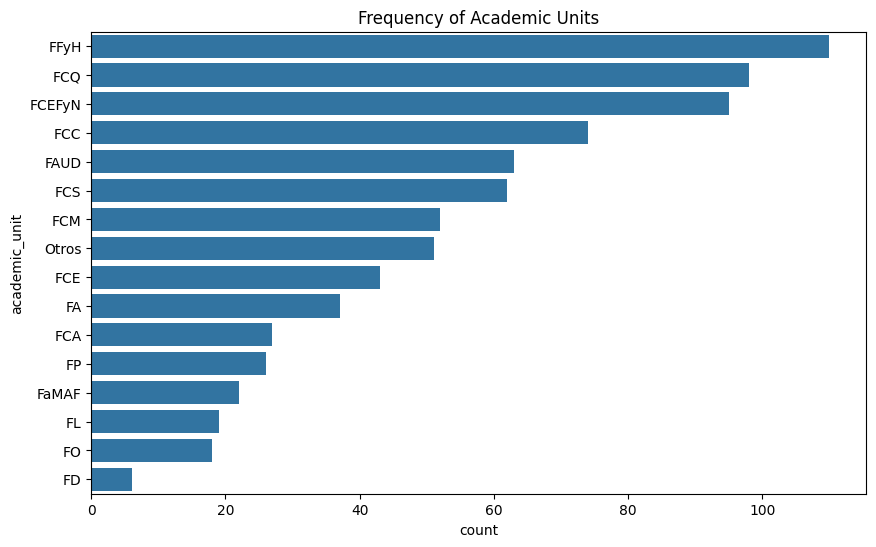

In [92]:
# explode comma-separated values into separate rows
df = df_enrollment.assign(
    academic_unit=df_enrollment["academic_unit"].str.split(",")
).explode("academic_unit")

# clean whitespace
df["academic_unit"] = df["academic_unit"].str.strip()

# count frequencies
counts = df["academic_unit"].value_counts().reset_index()
counts.columns = ["academic_unit", "count"]

# plot
plt.figure(figsize=(10,6))
sns.barplot(data=counts, x="count", y="academic_unit")
plt.title("Frequency of Academic Units")
plt.show()

## Read Portfolios

In [93]:
df_portfolios = pd.read_json(MERGED_DATA_DIRPATH / 'portfolios.json', lines=True)
PUBLIC_COLS_PORTFOLIOS = ['activos_institucionales_unc',
       'diferencial_grupo_internacional', 'recursos_naturales_biodiversidad',
       'experiencia_previa_internacional', 'desafio_global',
       'ejemplo_concreto', 'prestigio_unc', 'recursos_humanos_grupo',
       'infraestructura_disponible_unc', 'infraestructura_diferencial_unc',
       'infraestructura_ejemplo', 'extension_beneficios',
       'extension_relevancia', 'extension_articulaciones',
       'extension_alianzas', 'extension_redes', 'transferencia_mecanismos',
       'transferencia_productos', 'cultura_aspectos', 'cultura_impacto',
       'innovacion_capacidades', 'normativas', 'capital_social',
       'articulacion_sectores_productivos', 'diferencial_clave',
       'metodologias_otros_campos', 'aprendizajes_contexto_local',
       'metodologias_para_problematica', 'experiencia_transdisciplinar',
       'experiencia_situacional', 'experiencia_transferencia',
       'resultados_esperados']

In [95]:
df_portfolios.shape

(157, 34)

In [94]:
df_portfolios[PUBLIC_COLS_PORTFOLIOS].sample(3)

,activos_institucionales_unc,diferencial_grupo_internacional,recursos_naturales_biodiversidad,experiencia_previa_internacional,desafio_global,ejemplo_concreto,prestigio_unc,recursos_humanos_grupo,infraestructura_disponible_unc,infraestructura_diferencial_unc,...,capital_social,articulacion_sectores_productivos,diferencial_clave,metodologias_otros_campos,aprendizajes_contexto_local,metodologias_para_problematica,experiencia_transdisciplinar,experiencia_situacional,experiencia_transferencia,resultados_esperados
1,La UNC y el INICSA cuenta con activos instituc...,Nuestro grupo investiga la acción de la melato...,None,Universidades,Mi investigación aborda el desafío global de l...,Un ejemplo concreto de aplicación es la preven...,NaN,Contamos con un equipo multidisciplinario comp...,Contamos con laboratorios de la Cátedra de Bio...,None,...,None,None,"La infraestructura de laboratorios de la UNC, ...",None,NaN,None,None,None,None,Se espera ampliar y profundizar los hallazgos ...
108,Necesitaríamos nosotros los médicos asistencia...,Nuestro grupo investiga junto a entidades de a...,La contaminación ambiental junto al creciente ...,IDIBAPS - ERS,mi investigacion aborda las consecuencia negat...,investigamos marcadores biológicos de detecció...,NaN,medicos con experticia en enfermedades respira...,laboratorio de analisis clinicos- inmunoologic...,fomentar mas el analisis celular en esputo ind...,...,Los centros de salud primaria aportan experien...,Trabajamos con laboratorios locales en el desa...,La red de Sanatorio Allende junto con la hosp...,Estas técnicas que utilizamos son aplicables a...,NaN,análisis de muestras mediante métodos no invas...,No aun,Aportamos nuevos conocimientos de diagnostico ...,Trasferimos conocimientos e implementación de ...,"identificar marcador sensible, especifico para..."
82,La UNC aporta un conjunto de activos instituci...,Nuestro valor diferencial parte de una perspec...,Córdoba ha sido históricamente un cruce de cam...,Ninguna,"1. Nuestra labor contribuye al ODS 11, salvagu...",Entre 2018 y 2024 digitalizamos y catalogamos ...,NaN,Contamos con referentes internacionales en el ...,Equipamiento adquirido durante el PRIMAR-TP 32...,El láser Nd:YAG del Centro Láser de Ciencias M...,...,None,Colaboramos con los cuerpos artísticos profesi...,Nuestros mayores activos son la excepcional co...,Nuestro equipo aplica varias metodologías con ...,NaN,Nuestro grupo emplea escaneo de formato libro ...,En el proyecto PRIMAR-TP (2018-2022) articulam...,En los proyectos de catalogación de archivos c...,En colaboración con la Biblioteca Elma K. de E...,Esperamos publicar dos monográficos y edicione...


Calculate intersection of enrolled people with portfolios

In [88]:
merged_enrollment_portfolio = df_enrollment[['name', 'gender', 'cuit']]\
    .merge(df_portfolios[['email', 'cuit']], on="cuit", how='left')

print(f"Enrolled people with portfolios: {len(merged_enrollment_portfolio[~merged_enrollment_portfolio.email.isna()])}")
print(f"Enrolled people without portfolios: {len(merged_enrollment_portfolio[merged_enrollment_portfolio.email.isna()])}")

non_enrolled_portfolios = df_portfolios[['email', 'cuit']]\
    .merge(df_enrollment[['name', 'cuit']], on="cuit", how='left')
print(f"People with portfolios but not enrolled: {len(non_enrolled_portfolios[non_enrolled_portfolios.name.isna()])}")

Enrolled people with portfolios: 143
Enrolled people without portfolios: 621
People with portfolios but not enrolled: 18


## Read publications

In [97]:
df_articles = pd.read_json(MERGED_DATA_DIRPATH / 'articles.json', lines=True)
PUBLIC_COLS_ARTICLES = ['autores', 'titulo', 'resumen']
df_articles.shape

(10526, 5)

In [54]:
df_articles[PUBLIC_COLS_ARTICLES].sample(10)

,autores,titulo,resumen
957,"RODRIGUEZ ROCHA, EDUARDO; GÓMEZ, PABLO SEBASTIÁN","Origen de Clase, Diploma Educativo y Expectati...",l objetivo del artículo consiste en explorar l...
123,IVÁN ANGIONO; NICOLÁS ANDRUSKIEWITSCH; AGUSTÍN...,Liftings via cocycle deformations,e develop a strategy to compute all liftings o...
1457,AYELÉN ELIANA BRANCA; GABRIELA GIACOMELLI,La categoría de dependencia en la perspectiva ...,as teorías marxistas de la dependencia (TMD) s...
6,G. J. SIBONA; C. E. BUDDE; D. P. PRATO,A Correlated Majority Model,e extend and solve analytically a bichromatic ...
1555,"FUNES, MARIANA","Gentrificacion, desarrollo y postergacion: dos...",l presente artículo se enmarca en el paradigma...
1834,"AROMOKEYE, DAVID A.; WILLIS-PORATTI, GRACIANA;...",Global warming facilitated environmental chang...,apid melting of the Western Antarctic Peninsul...
301,"CAPDEVIELLE, JULIETA",(Re)Pensando el sistema educativo bajo el neol...,Intentar abordar el lugar de la escuela en la ...
1222,"RECHE, FEDERICO HERNÁN","¿Crecimiento, desarrollo o «milagro»? Aportes ...",l presente trabajo propone una interpretación ...
835,JONATHAN D. G. JONES,Subcellular localization of the Hpa RxLR effec...,ilamentous phytopathogens form sophisticated i...
1746,"BELTRAMONE, DIEGO ANTONIO",The role of touchscreens for learning process ...,owadays touch technologies have become part of...


## Read Projects

In [98]:
df_projects = pd.read_json(MERGED_DATA_DIRPATH / 'projects.json', lines=True)
PUBLIC_COLS_PROJECTS = ['titulo_proyecto', 'resumen_proyecto', 'nombre', 'fecha_alta']
df_projects.shape

(4620, 20)

In [56]:
df_projects[PUBLIC_COLS_PROJECTS].sample(10)

,titulo_proyecto,resumen_proyecto,nombre,fecha_alta
10,Prácticas de enseñanza universitarias. Traccio...,"La presente investigación surge, por un lado, ...",MARIEL ELIZABETH,2018-05-12 14:38:02
390,Nanoestructuras magnéticas,El presente plan contempla el estudio de nanoe...,MARÍA CECILIA,2013-12-12 12:54:53
592,"Estudios interculturales, transdisciplinares e...",os restos humanos indígenas de interés arqueol...,MARIANA,2023-07-20 10:14:11
420,Adquisicion de un Medidor Multiparametrico Dig...,El Medidor Multiparamétrico Digital es un equi...,MARÍA GUADALUPE,2023-09-18 13:50:29
226,Traslado nueva consola para RMN 400 MHz,Este proyecto tiene como objetivo cubrir los g...,ALEJANDRO MANUEL,2022-04-08 16:50:50
146,Rol de la Proteína Específica de Leucocitos 1 ...,Las células dendríticas (DCs) son los leucocit...,VÍCTOR GABRIEL,2018-04-09 13:16:05
248,Arqueología y Ecotoxicología de basurales en l...,En el presente proyecto multidisciplinario se ...,EDUARDO DANIEL,2019-05-15 15:12:55
73,Evaluación epidemiológica del Dolor Crónico: s...,El dolor crónico es motivo de consulta frecuen...,PATRICIA FABIANA,2014-02-26 11:12:45
452,"Medios, tecnologías y contenidos audiovisuales...",El proyecto continúa con la indagación iniciad...,GUILLERMO EDUARDO,2015-12-12 22:41:34
731,INVESTIGACIÓN CON INTERVENCIÓN: VALIDACIÓN Y E...,La OMS establece la importancia de diseñar int...,MÓNICA EDITH,2018-06-06 09:45:51
